In [1]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\akshara\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
df = pd.read_csv("amazonreviews.tsv", sep="\t")

print(df.head())
print(df.shape)

  label                                             review
0   pos  Stuning even for the non-gamer: This sound tra...
1   pos  The best soundtrack ever to anything.: I'm rea...
2   pos  Amazing!: This soundtrack is my favorite music...
3   pos  Excellent Soundtrack: I truly like this soundt...
4   pos  Remember, Pull Your Jaw Off The Floor After He...
(10000, 2)


In [3]:
df = pd.read_csv("amazonreviews.tsv", sep="\t")

print(df.head())
print(df.shape)


  label                                             review
0   pos  Stuning even for the non-gamer: This sound tra...
1   pos  The best soundtrack ever to anything.: I'm rea...
2   pos  Amazing!: This soundtrack is my favorite music...
3   pos  Excellent Soundtrack: I truly like this soundt...
4   pos  Remember, Pull Your Jaw Off The Floor After He...
(10000, 2)


In [4]:
print(df.isnull().sum())

label     0
review    0
dtype: int64


In [5]:
df.drop_duplicates(inplace=True)

print(df.shape)

(10000, 2)


In [6]:
stop_words = set(stopwords.words('english'))

def preprocess(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = text.split()

    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

df['clean_review'] = df['review'].apply(preprocess)

In [7]:
df[['review','clean_review']].head()

,review,clean_review
0,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


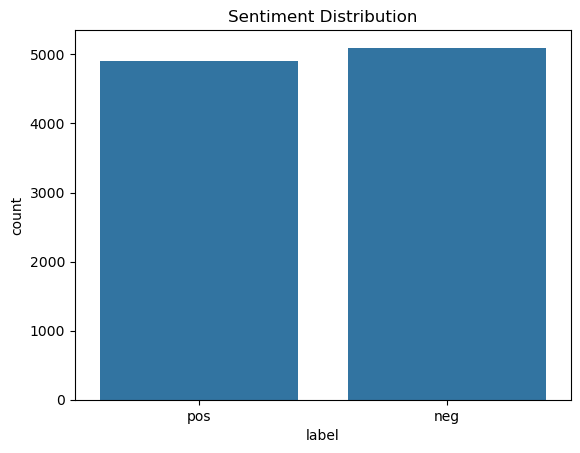

In [8]:
sns.countplot(x='label', data=df)

plt.title("Sentiment Distribution")
plt.show()

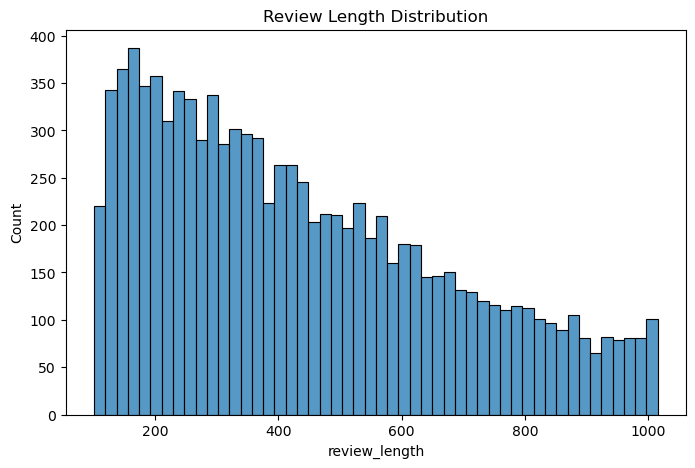

In [9]:
df['review_length'] = df['review'].astype(str).apply(len)

plt.figure(figsize=(8,5))

sns.histplot(df['review_length'], bins=50)

plt.title("Review Length Distribution")

plt.show()

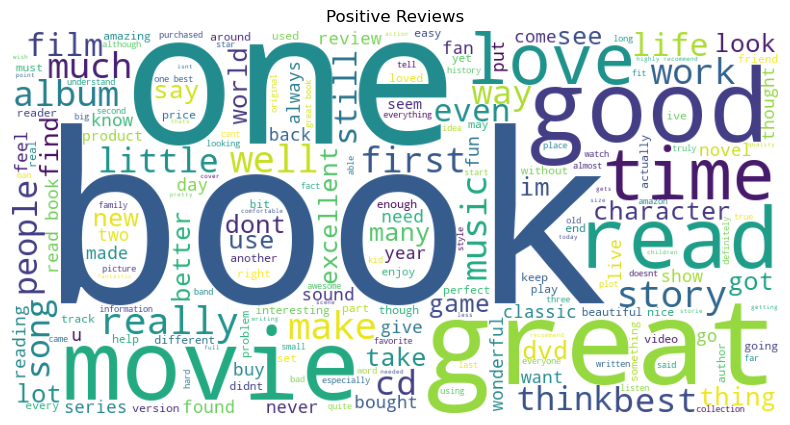

In [10]:
positive_text = " ".join(
    df[df['label']=='pos']['clean_review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Positive Reviews")

plt.show()

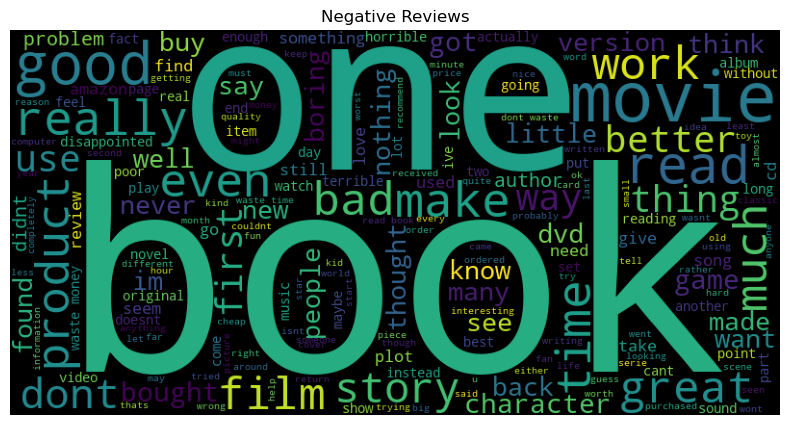

In [11]:
negative_text = " ".join(
    df[df['label']=='neg']['clean_review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='black'
).generate(negative_text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Negative Reviews")

plt.show()

In [12]:
positive_words = positive_text.split()

print(
    Counter(positive_words).most_common(20)
)

[('book', 3313), ('great', 2087), ('one', 1835), ('good', 1635), ('read', 1553), ('like', 1268), ('movie', 1085), ('would', 943), ('love', 902), ('time', 871), ('well', 854), ('really', 827), ('best', 801), ('get', 793), ('story', 713), ('first', 708), ('much', 650), ('cd', 581), ('music', 559), ('also', 557)]


In [13]:
negative_words = negative_text.split()

print(
    Counter(negative_words).most_common(20)
)

[('book', 3184), ('one', 2022), ('like', 1547), ('movie', 1465), ('would', 1438), ('dont', 1240), ('read', 1187), ('get', 1139), ('good', 1134), ('time', 1034), ('even', 898), ('buy', 814), ('really', 778), ('much', 769), ('bad', 749), ('money', 744), ('first', 736), ('could', 658), ('better', 656), ('great', 632)]


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['clean_review']

y = df['label']

tfidf = TfidfVectorizer(
    max_features=5000
)

X_tfidf = tfidf.fit_transform(X)

print(X_tfidf.shape)

(10000, 5000)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

y_pred_lr = lr.predict(
    X_test
)

In [17]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print(
    accuracy_score(
        y_test,
        y_pred_lr
    )
)

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

0.8525
              precision    recall  f1-score   support

         neg       0.85      0.86      0.86      1019
         pos       0.85      0.85      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



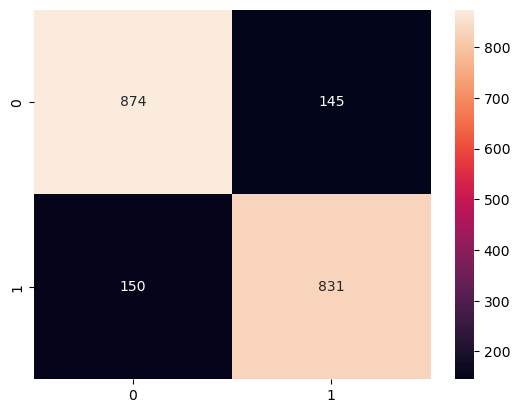

In [18]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.show()

In [19]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(
    X_train,
    y_train
)

y_pred_svm = svm.predict(
    X_test
)

In [20]:
print(
    accuracy_score(
        y_test,
        y_pred_svm
    )
)

print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

0.843
              precision    recall  f1-score   support

         neg       0.85      0.84      0.84      1019
         pos       0.83      0.85      0.84       981

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



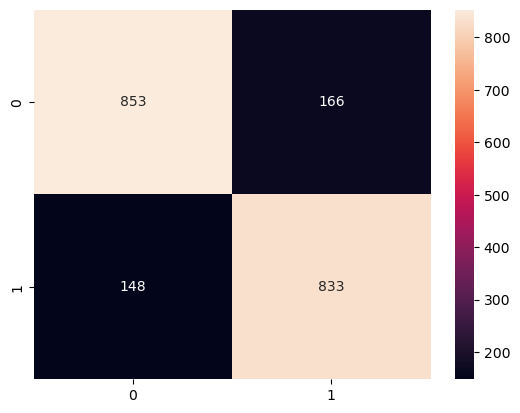

In [21]:
cm = confusion_matrix(
    y_test,
    y_pred_svm
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.show()

In [22]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    lr,
    X_tfidf,
    y,
    cv=5
)

print(scores)

print(scores.mean())

[0.8595 0.8335 0.828  0.831  0.849 ]
0.8402


In [23]:
results = pd.DataFrame({
    'Model':['Logistic Regression','SVM'],
    'Accuracy':[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_svm)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression    0.8525
1                  SVM    0.8430


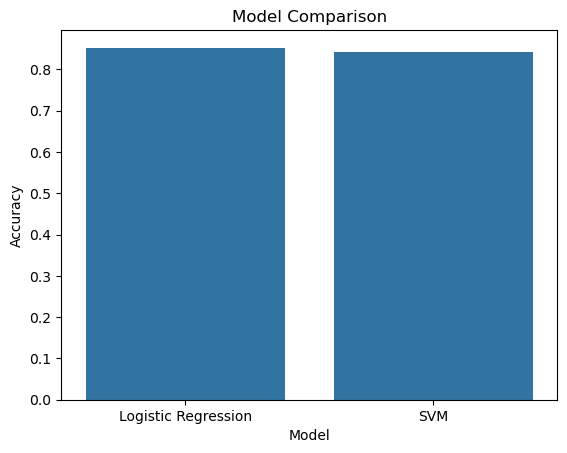

In [24]:
sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title("Model Comparison")

plt.show()